# California Real Estate Price Prediction: LightGBM Analysis

## Project Overview
This notebook implements an end-to-end regression pipeline to predict the close price of residential properties in California. The workflow includes rigorous data filtering to isolate single-family residences, outlier detection to ensure data quality, and the training of an optimized LightGBM regressor.


## Workflow Summary

### 1. Data Preprocessing
  * **Target Variable:** Log-transformation (`log1p`) of the `ClosePrice` variable to normalize the distribution.
  * **Cleaning:** Aggregated 10 months of raw transaction data (Jan–Oct 2025); filtered strictly for "Single Family Residence" property subtypes and removed records with negative physical attributes.
  * **Imputation:** Strategy using Median for numerical columns (e.g., `YearBuilt`, `LotSizeAcres`) and Mode for categorical columns to handle missing values.

### 2. Feature Engineering
  * **Outlier Removal:** Applied the Interquartile Range (IQR) method to remove extreme outliers in physical features such as `LivingArea` and `LotSizeAcres`.
  * **Transformation:** Mapped boolean indicators (e.g., `PoolPrivateYN`, `FireplaceYN`) to binary numerical formats (1/0) for model compatibility.
  * **Selection:** Curated a subset of high-impact features including `DaysOnMarket`, `Latitude/Longitude`, and `BathroomsTotalInteger`.

### 3. Modeling
  * **Algorithm:** Light Gradient Boosting Machine (LGBMRegressor).
  * **Optimization:** Hyperparameters (`learning_rate`, `max_depth`, `n_estimators`, `reg_lambda`) were tuned via 5-fold Grid Search Cross-Validation to maximize R² score.
  * **Evaluation Protocol:** Utilized percentiles (middle 99%) to trim extreme price anomalies during final metric calculation.


## Performance
### 1. R²
  * **Final Model:** 0.87 (on middle 99% of data).
  * **Baseline Model:** 0.40.
### 2. MdAPE
  * **Final Model:** 7.7%.
  * **Baseline Model:** 23.6%.
* **Improvement:** Achieved a substantial boost in explanatory power (**+0.47 R²**) and reduced the Median Absolute Percentage Error by approximately **67%** compared to the baseline.

# 1) Libraries

In [7]:
# Import libraries
import glob
import os
import pandas as pd
import numpy as np
import time as tm
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
import lightgbm as lgb
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_percentage_error

# 2) Datasets

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
# Import datasets (add September & October)
month1 = pd.read_csv('/content/drive/MyDrive/IDX Exchange DS 31/Datasets/Train/CRMLSSold202501_filled.csv')
month2 = pd.read_csv('/content/drive/MyDrive/IDX Exchange DS 31/Datasets/Train/CRMLSSold202502_filled.csv')
month3 = pd.read_csv('/content/drive/MyDrive/IDX Exchange DS 31/Datasets/Train/CRMLSSold202503_filled.csv')
month4 = pd.read_csv('/content/drive/MyDrive/IDX Exchange DS 31/Datasets/Train/CRMLSSold202504_filled.csv')
month5 = pd.read_csv('/content/drive/MyDrive/IDX Exchange DS 31/Datasets/Train/CRMLSSold202505_filled.csv')
month6 = pd.read_csv('/content/drive/MyDrive/IDX Exchange DS 31/Datasets/Train/CRMLSSold202506_filled.csv')
month7 = pd.read_csv('/content/drive/MyDrive/IDX Exchange DS 31/Datasets/Train/CRMLSSold202507_filled.csv')
month8 = pd.read_csv('/content/drive/MyDrive/IDX Exchange DS 31/Datasets/Train/CRMLSSold202508_filled-2.csv')
month9 = pd.read_csv('/content/drive/MyDrive/IDX Exchange DS 31/Datasets/Test/CRMLSSold202509.csv')
month10 = pd.read_csv('/content/drive/MyDrive/IDX Exchange DS 31/Datasets/Test/CRMLSSold202510.csv')


/tmp/ipython-input-1586393849.py:7: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  month6 = pd.read_csv('/content/drive/MyDrive/IDX Exchange DS 31/Datasets/Train/CRMLSSold202506_filled.csv')


In [10]:
# Merge all months into one training dataset
all_months_df = pd.concat([month1, month2, month3, month4, month5, month6, month7, month8])

# Sort by ListingKey and CloseDate in descending order to keep the most recent entry
all_months_df = all_months_df.sort_values(by=['ListingKey', 'CloseDate'], ascending=[True, False])

# Drop duplicates based on ListingKey, keeping the first (most recent)
all_months_df = all_months_df.drop_duplicates(subset=['ListingKey'], keep='first')

# Look at basic stats info
display(all_months_df.head())
all_months_df.describe()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled
11,Southland,Southland,NaN,True,NaN,NaN,NaN,355000.0,421653552,mr.khatibi@yahoo.com,...,NaN,False,NaN,NaN,93550,0.0,24897.0,NaN,False,False
6,Mlslistings,Mlslistings,NaN,True,NaN,NaN,NaN,2300000.0,421658322,judy@carmelrealtycompany.com,...,NaN,NaN,NaN,Carmel Unified,93923,2000.0,1208354.0,NaN,False,False
8,Southland,Southland,Stone,False,NaN,NaN,False,6000.0,421825332,michelleclark@earthlink.net,...,2.0,False,2.0,Ventura Unified,93001,0.0,3458.0,NaN,False,False
12,SierraNorthValley,SierraNorthValley,NaN,NaN,NaN,NaN,NaN,799999.0,425322388,maya.noble@c21selectgroup.com,...,NaN,NaN,NaN,NaN,95973,NaN,43560.0,NaN,False,False
10,OrangeCounty,OrangeCounty,NaN,NaN,NaN,NaN,NaN,1658.0,425481230,vic@baysideproperties.net,...,NaN,NaN,NaN,NaN,92780,NaN,22216.0,NaN,False,False


,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,1.741480e+05,1.746850e+05,1.746830e+05,174656.000000,174662.000000,1.625200e+05,1.743990e+05,174685.000000,0.0,0.0,...,0.0,813.000000,0.0,142088.000000,1.601660e+05,93978.000000,151566.000000,120227.000000,1.600390e+05,0.0
mean,9.081970e+05,1.105663e+09,8.729720e+05,34.522780,-118.450216,1.923681e+03,8.367104e+05,43.571160,NaN,NaN,...,NaN,55.867159,NaN,1.364633,4.573026e+04,1.923631,1.758561,188.752041,4.075249e+05,NaN
std,6.116993e+06,1.621279e+07,5.631963e+06,1.606524,3.312564,4.224190e+04,1.366444e+06,66.757132,NaN,NaN,...,NaN,320.939921,NaN,0.481329,1.309844e+06,2.366616,3.380416,2201.578346,1.817986e+07,NaN
min,0.000000e+00,4.216536e+08,0.000000e+00,-34.608007,-159.523315,0.000000e+00,0.000000e+00,-288.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,2.250000e+04,1.101092e+09,1.990000e+04,33.732541,-118.534505,1.180000e+03,2.199950e+04,9.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.000000e+03,1.000000,1.000000,0.000000,5.227000e+03,NaN
50%,6.290000e+05,1.108352e+09,6.180000e+05,34.035584,-118.041030,1.581000e+03,6.199990e+05,22.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.198000e+03,2.000000,2.000000,0.000000,7.405000e+03,NaN
75%,1.078200e+06,1.112701e+09,1.058000e+06,34.292678,-117.320479,2.160000e+03,1.050000e+06,54.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,1.210000e+04,3.000000,2.000000,293.000000,1.350400e+04,NaN
max,1.390000e+09,1.130908e+09,9.700000e+08,47.684252,329.000000,1.702132e+07,1.375000e+08,3385.000000,NaN,NaN,...,NaN,6104.000000,NaN,2.000000,2.831400e+08,444.000000,500.000000,750000.000000,2.090880e+09,NaN


In [11]:
# Filter observations with our interested property types
all_months_df = all_months_df.loc[(all_months_df['PropertyType'] == 'Residential') & (all_months_df['PropertySubType'] == 'SingleFamilyResidence') & (all_months_df['StateOrProvince'] == 'CA')]

# Check the number of observations left
all_months_df.shape

(86466, 80)

In [12]:
# Sort by ListingKey and CloseDate in descending order to keep the most recent entry

test_dataset = pd.concat([month9, month10])

test_dataset = test_dataset.sort_values(by=['ListingKey', 'CloseDate'], ascending=[True, False])

# Drop duplicates based on ListingKey, keeping the first (most recent)
test_dataset_unique = test_dataset.drop_duplicates(subset=['ListingKey'], keep='first')

# Look at basic stats info
display(test_dataset_unique.head())
test_dataset_unique.describe()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
2,SanDiego,SanDiego,Wood,True,NaN,NaN,False,1695.0,445176588,mannybehar@yahoo.com,...,NaN,NaN,NaN,NaN,0.0,NaN,92126,0.0,NaN,NaN
1,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,NaN,12000.0,446914808,nleimers@hotmail.com,...,NaN,14253.0,NaN,False,NaN,NaN,92325,0.0,14253.0,NaN
2,PacificWest,PacificWest,NaN,True,NaN,NaN,NaN,299900.0,448373180,ocrealtorsteph@gmail.com,...,NaN,20.0,NaN,False,NaN,NaN,92595,0.0,871200.0,NaN
0,NorthSanLuisObispo,NorthSanLuisObispo,NaN,NaN,NaN,NaN,NaN,NaN,479293596,newlin@pacificaCRE.com,...,NaN,1807.0,NaN,NaN,NaN,NaN,93446,NaN,1807.0,NaN
1,HighDesert,HighDesert,NaN,True,NaN,NaN,NaN,120000.0,508553099,lrethier@aol.com,...,652x984,653400.0,NaN,False,NaN,NaN,92344,NaN,653400.0,NaN


,OriginalListPrice,ListingKey,ClosePrice,Latitude,Longitude,LivingArea,ListPrice,DaysOnMarket,FireplacesTotal,AboveGradeFinishedArea,...,ElementarySchoolDistrict,BelowGradeFinishedArea,CoveredSpaces,Stories,LotSizeArea,MainLevelBedrooms,GarageSpaces,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
count,4.552400e+04,4.566500e+04,4.566400e+04,45653.000000,45654.000000,42554.000000,4.558000e+04,45665.000000,0.0,0.0,...,0.0,230.000000,0.0,37876.000000,4.201500e+04,24829.000000,39898.000000,31700.000000,4.197800e+04,0.0
mean,9.459459e+05,1.123083e+09,9.903467e+05,34.546242,-118.489048,1811.435493,8.502776e+05,47.057243,NaN,NaN,...,NaN,84.447826,NaN,1.359515,4.845514e+04,1.931894,1.768309,199.377083,6.465230e+05,NaN
std,6.740963e+06,1.275719e+07,1.130856e+07,1.684989,2.741931,1266.012511,1.316044e+06,65.126505,NaN,NaN,...,NaN,396.791999,NaN,0.479865,2.218342e+06,1.441237,3.265341,3322.659821,2.395589e+07,NaN
min,1.500000e+00,4.451766e+08,0.000000e+00,0.000000,-124.167635,0.000000,1.500000e+00,-21.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,NaN
25%,1.000000e+05,1.118398e+09,8.500000e+04,33.743542,-118.554960,1180.000000,9.900000e+04,11.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,5.000000e+03,1.000000,1.000000,0.000000,5.227200e+03,NaN
50%,6.500000e+05,1.120349e+09,6.350000e+05,34.041378,-118.071881,1580.000000,6.445780e+05,27.000000,NaN,NaN,...,NaN,0.000000,NaN,1.000000,7.107000e+03,2.000000,2.000000,0.000000,7.400000e+03,NaN
75%,1.099000e+06,1.130472e+09,1.069125e+06,34.322247,-117.333213,2150.000000,1.080000e+06,61.000000,NaN,NaN,...,NaN,0.000000,NaN,2.000000,1.176750e+04,3.000000,2.000000,289.000000,1.350400e+04,NaN
max,7.988880e+08,1.145282e+09,9.895000e+08,157.000000,119.760500,94619.000000,7.500000e+07,2085.000000,NaN,NaN,...,NaN,3490.000000,NaN,2.000000,4.187423e+08,44.000000,400.000000,587800.000000,2.030288e+09,NaN


In [13]:
# Filter observations with our interested property types
test_dataset_unique = test_dataset_unique.loc[(test_dataset_unique['PropertyType'] == 'Residential') & (test_dataset_unique['PropertySubType'] == 'SingleFamilyResidence') & (test_dataset_unique['StateOrProvince'] == 'CA')]

# Check the number of observations left
test_dataset_unique.shape


(23479, 78)

# 3) Feature Selection

Based on initial exploratory data analysis (EDA) and recursive feature elimination in prior iterations, the following 14 features were selected. These variables capture location (`Latitude`, `Longitude`), size (`LivingArea`, `LotSizeAcres`), and property condition (`YearBuilt`, `Bathrooms`), which are the primary drivers of California real estate value.

In [14]:
filtered_all_month_df = all_months_df[['DaysOnMarket', 'Latitude', 'Longitude', 'BathroomsTotalInteger', 'LivingArea',
                                               'FireplaceYN', 'YearBuilt', 'ParkingTotal', 'BedroomsTotal', 'PoolPrivateYN',
                                               'LotSizeAcres', 'Stories', 'ClosePrice', 'ListingKey']]

filtered_test_data = test_dataset_unique[['DaysOnMarket', 'Latitude', 'Longitude', 'BathroomsTotalInteger', 'LivingArea',
                                   'FireplaceYN', 'YearBuilt', 'ParkingTotal', 'BedroomsTotal', 'PoolPrivateYN',
                                   'LotSizeAcres', 'Stories', 'ClosePrice', 'ListingKey']]

# 4) Data Processing

## Train-Test Split

In [15]:
# Create training and test datasets
X_train = filtered_all_month_df.drop(columns=['ClosePrice']).set_index("ListingKey")
y_train = filtered_all_month_df.set_index("ListingKey")['ClosePrice']
X_test = filtered_test_data.drop(columns=['ClosePrice']).set_index("ListingKey")
y_test = filtered_test_data.set_index("ListingKey")['ClosePrice']

## Impute Missing Values

In [16]:
X_train_nomissing = X_train.copy()
X_test_nomissing = X_test.copy()

In [17]:
### Step 1: Impute missing values for training dataset

missing_cols_train = X_train.columns[X_train.isnull().any()]
print(missing_cols_train)

Index(['Latitude', 'Longitude', 'BathroomsTotalInteger', 'LivingArea',
       'FireplaceYN', 'YearBuilt', 'ParkingTotal', 'PoolPrivateYN',
       'LotSizeAcres', 'Stories'],
      dtype='object')


In [18]:
for col in missing_cols_train:
  if X_train[col].dtype == 'object':
    X_train_nomissing[col] = X_train_nomissing[col].fillna(X_train_nomissing[col].mode()[0])
  else:
    X_train_nomissing[col] = X_train_nomissing[col].fillna(X_train_nomissing[col].median())

/tmp/ipython-input-3740749656.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_nomissing[col] = X_train_nomissing[col].fillna(X_train_nomissing[col].mode()[0])


In [19]:
missing_cols_train = X_train_nomissing.columns[X_train_nomissing.isnull().any()]
print(missing_cols_train)

Index([], dtype='object')


In [20]:
### Step 2: Impute missing values for test dataset

missing_cols_test = X_test.columns[X_test.isnull().any()]
print(missing_cols_test)

Index(['Latitude', 'Longitude', 'BathroomsTotalInteger', 'LivingArea',
       'FireplaceYN', 'YearBuilt', 'PoolPrivateYN', 'LotSizeAcres', 'Stories'],
      dtype='object')


In [21]:
for col in missing_cols_test:
    if X_test_nomissing[col].dtype == 'object':
        X_test_nomissing[col] = X_test_nomissing[col].fillna(X_test_nomissing[col].mode()[0])
    else:
        X_test_nomissing[col] = X_test_nomissing[col].fillna(X_test_nomissing[col].median())

/tmp/ipython-input-3478204511.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test_nomissing[col] = X_test_nomissing[col].fillna(X_test_nomissing[col].mode()[0])


In [22]:
missing_cols_test = X_test_nomissing.columns[X_test_nomissing.isnull().any()]
print(missing_cols_test)

Index([], dtype='object')


## Convert Data Types

In [23]:
# Map True/False to 1/0 for selected columns
cols_to_convert = ['PoolPrivateYN', 'FireplaceYN']

for col in cols_to_convert:
    X_train_nomissing[col] = X_train_nomissing[col].map({True: 1, False: 0})
    X_test_nomissing[col] = X_test_nomissing[col].map({True: 1, False: 0})

## Remove Impossible Values & Outliers (IQR Method)

In [24]:
X_train_nomissing.columns

Index(['DaysOnMarket', 'Latitude', 'Longitude', 'BathroomsTotalInteger',
       'LivingArea', 'FireplaceYN', 'YearBuilt', 'ParkingTotal',
       'BedroomsTotal', 'PoolPrivateYN', 'LotSizeAcres', 'Stories'],
      dtype='object')

In [25]:
# Step 1: Remove negative values

X_train_nonegative = X_train_nomissing[(X_train_nomissing['LivingArea'] > 0) &
                                      (X_train_nomissing['BedroomsTotal'] > 0) &
                                      (X_train_nomissing['BathroomsTotalInteger'] > 0) &
                                      (X_train_nomissing['LotSizeAcres'] > 0) &
                                      (X_train_nomissing['YearBuilt'] > 0) &
                                      (X_train_nomissing['DaysOnMarket'] > 0) &
                                      (X_train_nomissing['ParkingTotal'] >= 0) &
                                      (X_train_nomissing['Stories'] > 0)]

X_test_nonegative = X_test_nomissing[(X_test_nomissing['LivingArea'] > 0) &
                                    (X_test_nomissing['BedroomsTotal'] > 0) &
                                    (X_test_nomissing['BathroomsTotalInteger'] > 0) &
                                    (X_test_nomissing['LotSizeAcres'] > 0) &
                                    (X_test_nomissing['YearBuilt'] > 0) &
                                    (X_test_nomissing['DaysOnMarket'] > 0) &
                                    (X_test_nomissing['ParkingTotal'] >= 0) &
                                    (X_test_nomissing['Stories'] > 0)]

In [26]:
# Step 2: Remove outliers

def remove_outliers_iqr(df, numeric_cols):
    Q1 = df[numeric_cols].quantile(0.25)
    Q3 = df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = ~((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).any(axis=1)
    return df[mask]

# Apply outlier removal to numeric columns only
numeric_cols = ['DaysOnMarket', 'BathroomsTotalInteger', 'LivingArea', 'YearBuilt',
                'ParkingTotal', 'BedroomsTotal', 'LotSizeAcres', 'Stories']

X_train_cleaned = remove_outliers_iqr(X_train_nonegative, numeric_cols)
X_test_cleaned = remove_outliers_iqr(X_test_nonegative, numeric_cols)

# Display the shape of the dataframes before removing outliers
print("Shape of training data before outlier removal:", X_train_nonegative.shape)
print("Shape of training data after outlier removal:", X_train_cleaned.shape)

# Display the shape of the dataframes after removing outliers
print("Shape of test data before outlier removal:", X_test_nonegative.shape)
print("Shape of test data after outlier removal:", X_test_cleaned.shape)

# Keep only the corresponding rows in y
y_train_cleaned = y_train.loc[X_train_cleaned.index]
y_test_cleaned = y_test.loc[X_test_cleaned.index]

print("Shape of y_train after outlier removal:", y_train_cleaned.shape)
print("Shape of y_test after outlier removal:", y_test_cleaned.shape)

Shape of training data before outlier removal: (82684, 12)
Shape of training data after outlier removal: (55065, 12)
Shape of test data before outlier removal: (22522, 12)
Shape of test data after outlier removal: (15092, 12)
Shape of y_train after outlier removal: (55065,)
Shape of y_test after outlier removal: (15092,)


In [27]:
X_train_final = X_train_cleaned
X_test_final = X_test_cleaned

# Log transform target variable
y_train_final = np.log1p(y_train_cleaned)
y_test_final = np.log1p(y_test_cleaned)

# 5) Model Building & Optimization

In this section, I establish a predictive modeling framework to estimate property close prices. The process progresses from a linear baseline to an advanced gradient-boosting approach, with iterative hyperparameter tuning to maximize accuracy on the unseen test set.

### 1. Baseline Model - Linear Regression
* **Goal:** Establish a performance benchmark using a standard Linear Regression model.
* **Performance:** The baseline achieved an $R^2$ of 0.40 and a Median Absolute Percentage Error (MdAPE) of 23.6% on the evaluation set. This confirmed the need for a non-linear model to capture complex market dynamics.

### 2. Advanced Modeling - LightGBM
* **Algorithm:** I implemented a **Light Gradient Boosting Machine (LGBMRegressor)** to better handle feature interactions and non-linearities.
* **Hyperparameter Tuning:** The model underwent three rounds of optimization using `GridSearchCV` with 5-fold cross-validation. We systematically tuned parameters such as `max_depth`, `n_estimators`, and `learning_rate`.
* **Final Configuration:** The optimal model utilized `max_depth=8`, `n_estimators=1200`, and `learning_rate=0.1`.

### 3. Robust Evaluation Strategy
* To ensure our metrics reflect the model's performance on the vast majority of the market rather than anomalies, I evaluated both models on a **trimmed test dataset** (middle 99%).
* This process removed the top and bottom 0.5% of extreme price outliers, providing a more stable and representative assessment of the model's predictive power.

### Final Results
The optimized LightGBM model achieved an **$R^2$ of 0.87** and an **MdAPE of 7.7%**, significantly outperforming the baseline.

## Baseline: Linear Regression

In [28]:
# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_final, y_train_final)

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test_final)

# Convert predictions and actual values back to original scale
y_pred_linear_exp = np.expm1(y_pred_linear)
y_test_linear_exp = np.expm1(y_test_final)

In [29]:
# Calculate the 0.5% and 99.5% thresholds for MdAPE by price band
lower_bound_99 = np.percentile(y_test_linear_exp, 0.5)
upper_bound_99 = np.percentile(y_test_linear_exp, 99.5)

print(f"Trimming data outside: {lower_bound_99:,.2f} to {upper_bound_99:,.2f}")

# Create a Boolean Mask
mask_99 = (y_test_linear_exp >= lower_bound_99) & (y_test_linear_exp <= upper_bound_99)

# Apply the mask to all datasets
y_test_linear_trimmed_99 = y_test_linear_exp[mask_99]
y_pred_linear_trimmed_99 = y_pred_linear_exp[mask_99]

# Check the new size
print(f"Original Count: {len(y_test_linear_exp)}")
print(f"Trimmed Count:  {len(y_test_linear_trimmed_99)}")

# Calculate Metrics on the Trimmed Data (Middle 99%)
print("-" * 30)
print("METRICS ON TRIMMED DATA (Middle 99%) - Linear Regression")
print("R-squared:", r2_score(y_test_linear_trimmed_99, y_pred_linear_trimmed_99))
print("MAPD:", mean_absolute_percentage_error(y_test_linear_trimmed_99, y_pred_linear_trimmed_99) * 100)
mdape_trimmed_99 = np.median(np.abs((y_test_linear_trimmed_99 - y_pred_linear_trimmed_99) / y_test_linear_trimmed_99)) * 100
print("MdAPE:", mdape_trimmed_99)

Trimming data outside: 240,000.00 to 4,471,975.62
Original Count: 15092
Trimmed Count:  14947
------------------------------
METRICS ON TRIMMED DATA (Middle 99%) - Linear Regression
R-squared: 0.40315866613208673
MAPD: 30.938592226820273
MdAPE: 23.598363555506477


In [30]:
# Create a DataFrame using the TRIMMED data
df_linear_trimmed = pd.DataFrame({
    'y_true': y_test_linear_trimmed_99,
    'y_pred': y_pred_linear_trimmed_99
})

# Define the same bins and labels
bins = [0, 500_000, 1_000_000, 2_000_000, 5_000_000, 10_000_000, np.inf]
labels = ['<$500K', '$500K–$1M', '$1M–$2M', '$2M–$5M', '$5M–$10M', '$10M+']

# Apply the Price Band category
df_linear_trimmed['price_band'] = pd.cut(df_linear_trimmed['y_true'], bins=bins, labels=labels, right=False)

# Define MdAPE function (if not already defined)
def mdape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

# Group by price band and calculate MdAPE
mdape_by_band_linear_trimmed = df_linear_trimmed.groupby('price_band', observed=False).apply(
    lambda g: mdape(g['y_true'], g['y_pred'])
)

print("MdAPE by Price Band (Trimmed Data - Linear Regression):")
print(mdape_by_band_linear_trimmed)

MdAPE by Price Band (Trimmed Data - Linear Regression):
price_band
<$500K       53.108333
$500K–$1M    17.415313
$1M–$2M      23.741825
$2M–$5M      42.701430
$5M–$10M           NaN
$10M+              NaN
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3914650423.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mdape_by_band_linear_trimmed = df_linear_trimmed.groupby('price_band', observed=False).apply(


## Final Model: LightGBM

### First Round of Hyperparameter Tuning

In [31]:
# Define the model
lgbm = lgb.LGBMRegressor(
    random_state=1,
    objective='regression',
    n_jobs=1
)

# Define the grid
grid_lgbm = {
    'learning_rate': [0.1],

    'subsample': [1.0],
    'subsample_freq': [5],

    # Standard params
    'max_depth': [7, 8, 9],
    'n_estimators': [900, 950, 1000],
    'reg_lambda': [0.1],
    'colsample_bytree': [1.0],
}

cv = KFold(n_splits=5, shuffle=True, random_state=1)

# Set up the search
gscv_lgbm = GridSearchCV(
    lgbm,
    grid_lgbm,
    cv=cv,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

# Run
gscv_lgbm.fit(X_train_final, y_train_final)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006434 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1292
[LightGBM] [Info] Number of data points in the train set: 55065, number of used features: 12
[LightGBM] [Info] Start training from score 13.730009


GridSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
             estimator=LGBMRegressor(n_jobs=1, objective='regression',
                                     random_state=1),
             n_jobs=-1,
             param_grid={'colsample_bytree': [1.0], 'learning_rate': [0.1],
                         'max_depth': [7, 8, 9],
                         'n_estimators': [900, 950, 1000], 'reg_lambda': [0.1],
                         'subsample': [1.0], 'subsample_freq': [5]},
             scoring='r2', verbose=1)

In [32]:
print("Best Score:", gscv_lgbm.best_score_)
print("Best Params:", gscv_lgbm.best_params_)

Best Score: 0.8920123851087357
Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 1000, 'reg_lambda': 0.1, 'subsample': 1.0, 'subsample_freq': 5}


In [33]:
# Make predictions on the test set
y_pred = gscv_lgbm.best_estimator_.predict(X_test_final)

# Convert predictions and actual values back to original scale
y_pred_exp = np.expm1(y_pred)
y_test_exp = np.expm1(y_test_final)

In [34]:
# Calculate the 5% and 95% thresholds
lower_bound = np.percentile(y_test_exp, 5)
upper_bound = np.percentile(y_test_exp, 95)

print(f"Trimming data outside: {lower_bound:,.2f} to {upper_bound:,.2f}")

# Create a Boolean Mask
## This creates a list of True/False values for rows we want to keep
mask = (y_test_exp >= lower_bound) & (y_test_exp <= upper_bound)

# Apply the mask to all datasets
y_test_trimmed = y_test_exp[mask]
y_pred_trimmed = y_pred_exp[mask]

# Assuming X_test_final is a Pandas DataFrame
X_test_trimmed = X_test_final[mask]

# Check the new size
print(f"Original Count: {len(y_test_exp)}")
print(f"Trimmed Count:  {len(y_test_trimmed)}")

# Calculate Metrics on the Trimmed Data
print("-" * 30)
print("METRICS ON TRIMMED DATA (Middle 90%)")
print("R-squared:", r2_score(y_test_trimmed, y_pred_trimmed))
print("MAPD:", mean_absolute_percentage_error(y_test_trimmed, y_pred_trimmed) * 100)
mdape_trimmed = np.median(np.abs((y_test_trimmed - y_pred_trimmed) / y_test_trimmed)) * 100
print("MdAPE:", mdape_trimmed)

Trimming data outside: 391,000.00 to 2,300,000.00
Original Count: 15092
Trimmed Count:  13587
------------------------------
METRICS ON TRIMMED DATA (Middle 90%)
R-squared: 0.8295817815390637
MAPD: 10.648587635642354
MdAPE: 7.527036609326605


In [35]:
# Create a DataFrame using the TRIMMED data
df_trimmed = pd.DataFrame({
    'y_true': y_test_trimmed,
    'y_pred': y_pred_trimmed
})

# Define the same bins and labels
bins = [0, 500_000, 1_000_000, 2_000_000, 5_000_000, 10_000_000, np.inf]
labels = ['<$500K', '$500K–$1M', '$1M–$2M', '$2M–$5M', '$5M–$10M', '$10M+']

# Apply the Price Band category
df_trimmed['price_band'] = pd.cut(df_trimmed['y_true'], bins=bins, labels=labels, right=False)

# Define MdAPE function
def mdape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

# Group by price band and calculate MdAPE
mdape_by_band_trimmed = df_trimmed.groupby('price_band', observed=False).apply(
    lambda g: mdape(g['y_true'], g['y_pred'])
)

print("MdAPE by Price Band (Trimmed Data):")
print(mdape_by_band_trimmed)

MdAPE by Price Band (Trimmed Data):
price_band
<$500K        6.891911
$500K–$1M     6.584503
$1M–$2M       9.144073
$2M–$5M      11.294170
$5M–$10M           NaN
$10M+              NaN
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3383372971.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mdape_by_band_trimmed = df_trimmed.groupby('price_band', observed=False).apply(


### Second Round of Hyperparameter Tuning

In [36]:
# Define the model
lgbm = lgb.LGBMRegressor(
    random_state=1,
    objective='regression',
    n_jobs=1
)

# Define the grid
grid_lgbm = {
    'learning_rate': [0.1],

    'subsample': [1.0],
    'subsample_freq': [5],

    # Standard params
    'max_depth': [8],
    'n_estimators': [1000, 1100, 1200],
    'reg_lambda': [0.1],
    'colsample_bytree': [1.0],
}

cv = KFold(n_splits=5, shuffle=True, random_state=1)

# Set up the search
gscv_lgbm = GridSearchCV(
    lgbm,
    grid_lgbm,
    cv=cv,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

# Run
gscv_lgbm.fit(X_train_final, y_train_final)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005274 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1292
[LightGBM] [Info] Number of data points in the train set: 55065, number of used features: 12
[LightGBM] [Info] Start training from score 13.730009


GridSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
             estimator=LGBMRegressor(n_jobs=1, objective='regression',
                                     random_state=1),
             n_jobs=-1,
             param_grid={'colsample_bytree': [1.0], 'learning_rate': [0.1],
                         'max_depth': [8], 'n_estimators': [1000, 1100, 1200],
                         'reg_lambda': [0.1], 'subsample': [1.0],
                         'subsample_freq': [5]},
             scoring='r2', verbose=1)

In [37]:
print("Best Score:", gscv_lgbm.best_score_)
print("Best Params:", gscv_lgbm.best_params_)

Best Score: 0.8921269927635638
Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 1200, 'reg_lambda': 0.1, 'subsample': 1.0, 'subsample_freq': 5}


In [38]:
# Make predictions on the test set
y_pred = gscv_lgbm.best_estimator_.predict(X_test_final)

# Convert predictions and actual values back to original scale
y_pred_exp = np.expm1(y_pred)
y_test_exp = np.expm1(y_test_final)

In [39]:
# Calculate the 5% and 95% thresholds
lower_bound = np.percentile(y_test_exp, 5)
upper_bound = np.percentile(y_test_exp, 95)

print(f"Trimming data outside: {lower_bound:,.2f} to {upper_bound:,.2f}")

# Create a Boolean Mask
# This creates a list of True/False values for rows we want to keep
mask = (y_test_exp >= lower_bound) & (y_test_exp <= upper_bound)

# Apply the mask to all datasets
y_test_trimmed = y_test_exp[mask]
y_pred_trimmed = y_pred_exp[mask]

# Assuming X_test_final is a Pandas DataFrame
X_test_trimmed = X_test_final[mask]

# Check the new size
print(f"Original Count: {len(y_test_exp)}")
print(f"Trimmed Count:  {len(y_test_trimmed)}")

# Calculate Metrics on the Trimmed Data
print("-" * 30)
print("METRICS ON TRIMMED DATA (Middle 90%)")
print("R-squared:", r2_score(y_test_trimmed, y_pred_trimmed))
print("MAPD:", mean_absolute_percentage_error(y_test_trimmed, y_pred_trimmed) * 100)
mdape_trimmed = np.median(np.abs((y_test_trimmed - y_pred_trimmed) / y_test_trimmed)) * 100
print("MdAPE:", mdape_trimmed)

Trimming data outside: 391,000.00 to 2,300,000.00
Original Count: 15092
Trimmed Count:  13587
------------------------------
METRICS ON TRIMMED DATA (Middle 90%)
R-squared: 0.8303506323014462
MAPD: 10.610020749082748
MdAPE: 7.466177865236159


In [40]:
# Create a DataFrame using the TRIMMED data
df_trimmed = pd.DataFrame({
    'y_true': y_test_trimmed,
    'y_pred': y_pred_trimmed
})

# Define the same bins and labels
bins = [0, 500_000, 1_000_000, 2_000_000, 5_000_000, 10_000_000, np.inf]
labels = ['<$500K', '$500K–$1M', '$1M–$2M', '$2M–$5M', '$5M–$10M', '$10M+']

# Apply the Price Band category
df_trimmed['price_band'] = pd.cut(df_trimmed['y_true'], bins=bins, labels=labels, right=False)

# Define MdAPE function
def mdape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

# Group by price band and calculate MdAPE
mdape_by_band_trimmed = df_trimmed.groupby('price_band', observed=False).apply(
    lambda g: mdape(g['y_true'], g['y_pred'])
)

print("MdAPE by Price Band (Trimmed Data):")
print(mdape_by_band_trimmed)

MdAPE by Price Band (Trimmed Data):
price_band
<$500K        6.719730
$500K–$1M     6.602034
$1M–$2M       9.083355
$2M–$5M      11.460437
$5M–$10M           NaN
$10M+              NaN
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-3383372971.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mdape_by_band_trimmed = df_trimmed.groupby('price_band', observed=False).apply(


### Third Round of Hyperparameter Tuning

In [41]:
# Define the model
lgbm = lgb.LGBMRegressor(
    random_state=1,
    objective='regression',
    n_jobs=1
)

# Define the grid
grid_lgbm = {
    'learning_rate': [0.1],

    'subsample': [1.0],
    'subsample_freq': [5],

    # Standard params
    'max_depth': [8],
    'n_estimators': [1200],
    'reg_lambda': [0.1],
    'colsample_bytree': [1.0],
}

cv = KFold(n_splits=5, shuffle=True, random_state=1)

# Set up the search
gscv_lgbm = GridSearchCV(
    lgbm,
    grid_lgbm,
    cv=cv,
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

# Run
gscv_lgbm.fit(X_train_final, y_train_final)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003925 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1292
[LightGBM] [Info] Number of data points in the train set: 55065, number of used features: 12
[LightGBM] [Info] Start training from score 13.730009


GridSearchCV(cv=KFold(n_splits=5, random_state=1, shuffle=True),
             estimator=LGBMRegressor(n_jobs=1, objective='regression',
                                     random_state=1),
             n_jobs=-1,
             param_grid={'colsample_bytree': [1.0], 'learning_rate': [0.1],
                         'max_depth': [8], 'n_estimators': [1200],
                         'reg_lambda': [0.1], 'subsample': [1.0],
                         'subsample_freq': [5]},
             scoring='r2', verbose=1)

In [42]:
print("Best Score:", gscv_lgbm.best_score_)
print("Best Params:", gscv_lgbm.best_params_)

Best Score: 0.8921269927635638
Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 1200, 'reg_lambda': 0.1, 'subsample': 1.0, 'subsample_freq': 5}


In [43]:
# Make predictions on the test set
y_pred = gscv_lgbm.best_estimator_.predict(X_test_final)

# Convert predictions and actual values back to original scale
y_pred_exp = np.expm1(y_pred)
y_test_exp = np.expm1(y_test_final)

In [44]:
# Calculate the 5% and 95% thresholds
lower_bound = np.percentile(y_test_exp, 0.5)
upper_bound = np.percentile(y_test_exp, 99.5)

print(f"Trimming data outside: {lower_bound:,.2f} to {upper_bound:,.2f}")

# Create a Boolean Mask
# This creates a list of True/False values for rows we want to keep
mask = (y_test_exp >= lower_bound) & (y_test_exp <= upper_bound)

# Apply the mask to all datasets
y_test_trimmed = y_test_exp[mask]
y_pred_trimmed = y_pred_exp[mask]

# Assuming X_test_final is a Pandas DataFrame
X_test_trimmed = X_test_final[mask]

# Check the new size
print(f"Original Count: {len(y_test_exp)}")
print(f"Trimmed Count:  {len(y_test_trimmed)}")

# Calculate Metrics on the Trimmed Data
print("-" * 30)
print("METRICS ON TRIMMED DATA (Middle 99%)")
print("R-squared:", r2_score(y_test_trimmed, y_pred_trimmed))
print("MAPD:", mean_absolute_percentage_error(y_test_trimmed, y_pred_trimmed) * 100)
mdape_trimmed = np.median(np.abs((y_test_trimmed - y_pred_trimmed) / y_test_trimmed)) * 100
print("MdAPE:", mdape_trimmed)

Trimming data outside: 240,000.00 to 4,471,975.62
Original Count: 15092
Trimmed Count:  14947
------------------------------
METRICS ON TRIMMED DATA (Middle 99%)
R-squared: 0.8717403124992498
MAPD: 11.08538141650667
MdAPE: 7.718876346298824


In [45]:
# Create a DataFrame using the TRIMMED data
df_trimmed = pd.DataFrame({
    'y_true': y_test_trimmed,
    'y_pred': y_pred_trimmed
})

# Define the same bins and labels
bins = [0, 500_000, 1_000_000, 2_000_000, 5_000_000, 10_000_000, np.inf]
labels = ['<$500K', '$500K–$1M', '$1M–$2M', '$2M–$5M', '$5M–$10M', '$10M+']

# Apply the Price Band category
df_trimmed['price_band'] = pd.cut(df_trimmed['y_true'], bins=bins, labels=labels, right=False)

# Define MdAPE function (if not already defined)
def mdape(y_true, y_pred):
    return np.median(np.abs((y_true - y_pred) / y_true)) * 100

# Group by price band and calculate MdAPE
mdape_by_band_trimmed = df_trimmed.groupby('price_band', observed=False).apply(
    lambda g: mdape(g['y_true'], g['y_pred'])
)

print("MdAPE by Price Band (Trimmed Data):")
print(mdape_by_band_trimmed)

MdAPE by Price Band (Trimmed Data):
price_band
<$500K        7.809393
$500K–$1M     6.602034
$1M–$2M       9.083355
$2M–$5M      12.044021
$5M–$10M           NaN
$10M+              NaN
dtype: float64


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipython-input-1934489145.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mdape_by_band_trimmed = df_trimmed.groupby('price_band', observed=False).apply(


### Feature Importance

/tmp/ipython-input-401556567.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importances, palette='viridis')


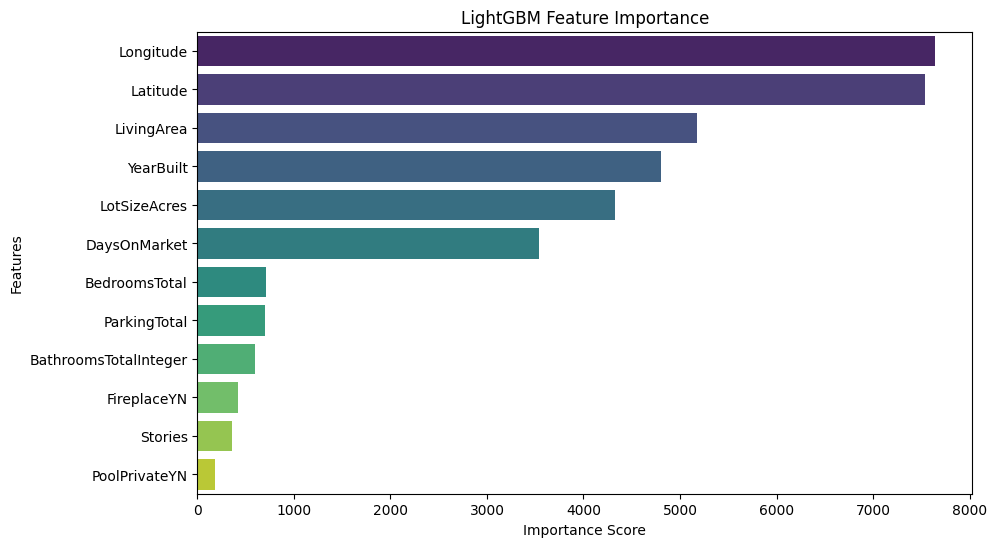

In [46]:
# Extract feature importances
importances = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': gscv_lgbm.best_estimator_.feature_importances_
}).sort_values(by='importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances, palette='viridis')
plt.title('LightGBM Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### Prediction Plot

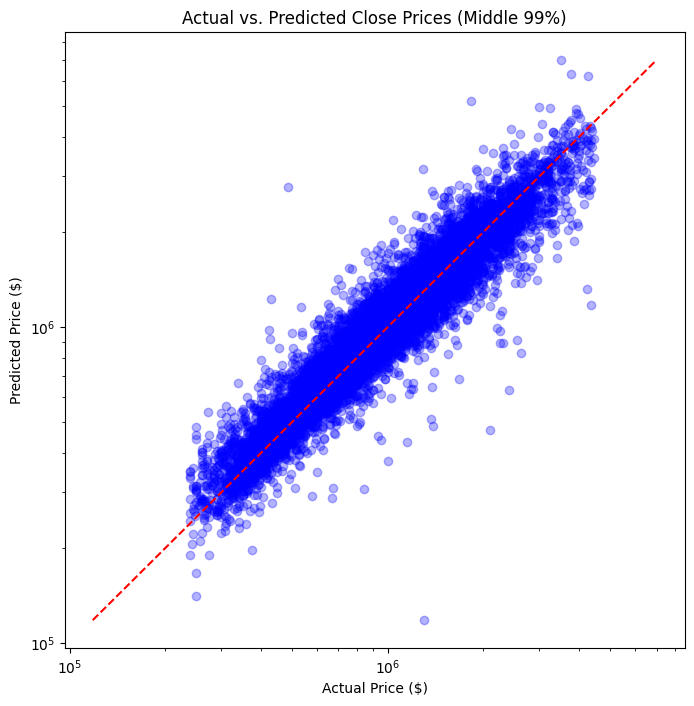

In [47]:
# Plot Actual vs Predicted on Log Scale (or exp scale)
plt.figure(figsize=(8, 8))
plt.scatter(y_test_trimmed, y_pred_trimmed, alpha=0.3, color='blue')

# Plot the perfect prediction line
max_val = max(y_test_trimmed.max(), y_pred_trimmed.max())
min_val = min(y_test_trimmed.min(), y_pred_trimmed.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.title('Actual vs. Predicted Close Prices (Middle 99%)')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.xscale('log') # Optional: Use log scale if the range is huge
plt.yscale('log')
plt.show()